In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

DATA_CLEANED   = Path('../data/processed/telecom_churn_cleaned.parquet')
DATA_PROCESSED = Path('../data/processed/')
FIGURES_PATH   = Path('../notebooks/figures')

df = pd.read_parquet(DATA_CLEANED)

print(f"Shape loaded      : {df.shape}")
print(f"Churn rate        : {df['churn'].mean():.1%}")
print(f"Nulls             : {df.isnull().sum().sum()}")
print(f"\nColumns available :\n{list(df.columns)}")

Shape loaded      : (15025, 17)
Churn rate        : 47.4%
Nulls             : 0

Columns available :
['age', 'gender', 'senior_citizen', 'has_partner', 'has_dependents', 'tenure_months', 'contract', 'internet_service', 'online_security', 'tech_support', 'streaming_tv', 'num_services', 'monthly_charges', 'total_charges', 'payment_method', 'paperless_billing', 'churn']


In [23]:
# Keep original cleaned copy as reference
df_baseline = df.copy()

print("═" * 55)
print("  FEATURE ENGINEERING PLAN")
print("═" * 55)

plan = {
    "tenure_group"          : "Bucket tenure → non-linearity",
    "charges_per_month"     : "TotalCharges / tenure → consistency",
    "is_new_customer"       : "tenure ≤ 6 months → highest risk flag",
    "contract_risk_score"   : "Ordinal encoding of contract risk",
    "has_fiber_no_support"  : "Fiber optic AND no tech support",
    "service_value_ratio"   : "num_services / monthly_charges",
    "monthly_charge_group"  : "Bucket charges → price sensitivity",
    "senior_alone"          : "Senior + no partner + no dependents",
    "payment_risk_score"    : "Electronic check = highest churn risk",
    "tenure_contract_risk"  : "Interaction: new + month-to-month",
}

print(f"\n{'Feature':<28} {'Rationale'}")
print("-" * 65)
for feat, rationale in plan.items():
    print(f"  {feat:<26} {rationale}")

print(f"\nTotal new features planned : {len(plan)}")

═══════════════════════════════════════════════════════
  FEATURE ENGINEERING PLAN
═══════════════════════════════════════════════════════

Feature                      Rationale
-----------------------------------------------------------------
  tenure_group               Bucket tenure → non-linearity
  charges_per_month          TotalCharges / tenure → consistency
  is_new_customer            tenure ≤ 6 months → highest risk flag
  contract_risk_score        Ordinal encoding of contract risk
  has_fiber_no_support       Fiber optic AND no tech support
  service_value_ratio        num_services / monthly_charges
  monthly_charge_group       Bucket charges → price sensitivity
  senior_alone               Senior + no partner + no dependents
  payment_risk_score         Electronic check = highest churn risk
  tenure_contract_risk       Interaction: new + month-to-month

Total new features planned : 10


In [24]:
print("── FEATURE 1 : tenure_group ──")

# Why bucketing?
# tenure has a non-linear relationship with churn.
# A customer at month 5 behaves very differently from month 13.
# XGBoost can learn this, but an explicit bucket helps
# smaller models and improves interpretability.

def create_tenure_group(tenure: pd.Series) -> pd.Series:
    """
    Bucket tenure into 4 risk segments based on
    observed churn patterns in the EDA.
    """
    return pd.cut(
        tenure,
        bins=[0, 6, 12, 24, 36, 72],
        labels=['0-6m', '7-12m', '13-24m', '25-36m', '37-72m'],
        right=True
    )

df['tenure_group'] = create_tenure_group(df['tenure_months'])

# Validate
print(f"\nValue counts :")
print(df['tenure_group'].value_counts().sort_index().to_string())

# Churn rate per bucket — the key validation
churn_by_tenure = (
    df.groupby('tenure_group', observed=True)['churn']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'n'})
)
churn_by_tenure['churn_rate'] = (
    churn_by_tenure['churn_rate'] * 100
).round(1)

print(f"\nChurn rate per tenure group :")
print(churn_by_tenure.to_string())
print("\n→ Expected: churn_rate decreases as tenure increases")
print("→ If not — the feature still captures a real pattern")

── FEATURE 1 : tenure_group ──

Value counts :
tenure_group
0-6m      3177
7-12m     1906
13-24m    2680
25-36m    2231
37-72m    5031

Churn rate per tenure group :
              churn_rate     n
tenure_group                  
0-6m                84.3  3177
7-12m               73.7  1906
13-24m              52.2  2680
25-36m              39.3  2231
37-72m              15.3  5031

→ Expected: churn_rate decreases as tenure increases
→ If not — the feature still captures a real pattern


In [25]:
print("── FEATURE 2 : charges_per_month ──")

# Why this feature?
# total_charges / tenure = average monthly payment over lifetime.
# If this differs significantly from current monthly_charges,
# it signals pricing changes or inconsistent billing.
# High ratio = customer paying more recently = potential dissatisfaction.

df['charges_per_month'] = (
    df['total_charges'] / df['tenure_months'].replace(0, 1)
).round(2)

# Validate: should be close to monthly_charges for most customers
diff = (df['charges_per_month'] - df['monthly_charges']).abs()
print(f"\nDifference vs monthly_charges :")
print(f"  Mean absolute diff  : ${diff.mean():.2f}")
print(f"  Max absolute diff   : ${diff.max():.2f}")
print(f"  Customers with >$10 diff : {(diff > 10).sum()}")

# Churn rate by charges_per_month quartile
df['cpq_quartile'] = pd.qcut(
    df['charges_per_month'], q=4,
    labels=['Q1 Low', 'Q2', 'Q3', 'Q4 High']
)
churn_by_cpq = (
    df.groupby('cpq_quartile', observed=True)['churn']
    .mean() * 100
).round(1)
print(f"\nChurn rate by charges_per_month quartile :")
print(churn_by_cpq.to_string())

# Drop helper column
df.drop(columns=['cpq_quartile'], inplace=True)

── FEATURE 2 : charges_per_month ──

Difference vs monthly_charges :
  Mean absolute diff  : $3.80
  Max absolute diff   : $747.42
  Customers with >$10 diff : 493

Churn rate by charges_per_month quartile :
cpq_quartile
Q1 Low     43.2
Q2         41.8
Q3         53.5
Q4 High    51.3


In [26]:
print("── FEATURE 3 : is_new_customer ──")

# Why this feature?
# EDA showed customers with tenure ≤ 6 months churn at ~47%.
# This binary flag captures the highest-risk segment explicitly.
# It also helps the model in the absence of other strong signals
# for very new customers (no total_charges history, etc.)

df['is_new_customer'] = (df['tenure_months'] <= 6).astype(int)

# Validate
n_new    = df['is_new_customer'].sum()
n_total  = len(df)
churn_new    = df[df['is_new_customer'] == 1]['churn'].mean() * 100
churn_old    = df[df['is_new_customer'] == 0]['churn'].mean() * 100
churn_global = df['churn'].mean() * 100

print(f"\nNew customers (tenure ≤ 6m) : {n_new:,} ({n_new/n_total:.1%})")
print(f"\nChurn rate comparison :")
print(f"  New customers   : {churn_new:.1f}%")
print(f"  Other customers : {churn_old:.1f}%")
print(f"  Global rate     : {churn_global:.1f}%")
print(f"\nChurn multiplier for new customers : "
      f"{churn_new/churn_global:.1f}×")
print("→ A multiplier > 1.5 confirms the feature is meaningful")

── FEATURE 3 : is_new_customer ──

New customers (tenure ≤ 6m) : 3,177 (21.1%)

Churn rate comparison :
  New customers   : 84.3%
  Other customers : 37.5%
  Global rate     : 47.4%

Churn multiplier for new customers : 1.8×
→ A multiplier > 1.5 confirms the feature is meaningful


In [27]:
print("── FEATURE 4 : contract_risk_score ──")

# Why ordinal encoding here instead of one-hot?
# Contract type has a natural risk ordering:
#   Month-to-month (highest risk) > One year > Two year (lowest risk)
# An ordinal score preserves this ordering and reduces dimensionality.
# We keep the original one-hot columns too — both will be tested.

contract_risk_map = {
    'Month-to-month' : 2,
    'One year'       : 1,
    'Two year'       : 0
}

df['contract_risk_score'] = (
    df['contract'].map(contract_risk_map)
)

# Validate
print(f"\nValue counts :")
print(df['contract_risk_score'].value_counts().sort_index().to_string())

churn_by_score = (
    df.groupby('contract_risk_score')['churn']
    .mean() * 100
).round(1)
print(f"\nChurn rate per risk score :")
print(churn_by_score.to_string())
print("\n→ Expected: churn_rate increases with risk score (0 → 2)")

# Correlation with churn
corr = df['contract_risk_score'].corr(df['churn'])
print(f"\nCorrelation with churn : {corr:.3f}")
print("→ Should be positive and > 0.15 to be meaningful")

── FEATURE 4 : contract_risk_score ──

Value counts :
contract_risk_score
2    8245
1    3609
0    3171

Churn rate per risk score :
contract_risk_score
2    70.3
1    23.8
0    14.9

→ Expected: churn_rate increases with risk score (0 → 2)

Correlation with churn : 0.484
→ Should be positive and > 0.15 to be meaningful


In [28]:
print("── FEATURE 5 : has_fiber_no_support ──")

# Why this interaction feature?
# EDA showed Fiber optic customers WITHOUT tech support
# churn at nearly 2× the rate of those WITH tech support.
# This interaction is not captured by either feature alone.
# It represents a business insight:
# Fiber is high-bandwidth → more technical issues →
# no support = frustration = churn.

df['has_fiber_no_support'] = (
    (df['internet_service'] == 'Fiber optic') &
    (df['tech_support'] == 'No')
).astype(int)

df['has_fiber_with_support'] = (
    (df['internet_service'] == 'Fiber optic') &
    (df['tech_support'] == 'Yes')
).astype(int)

# Validate
groups = {
    'Fiber + No Support'   : df['has_fiber_no_support'] == 1,
    'Fiber + With Support' : df['has_fiber_with_support'] == 1,
    'DSL'                  : df['internet_service'] == 'DSL',
    'No Internet'          : df['internet_service'] == 'No',
}

print(f"\nChurn rate by internet + support combination :")
for label, mask in groups.items():
    subset = df[mask]
    rate   = subset['churn'].mean() * 100
    n      = len(subset)
    print(f"  {label:<26} {rate:>5.1f}%  (n={n:,})")

print("\n→ has_fiber_no_support should show highest churn rate")
print("→ This confirms the interaction is real and predictive")

── FEATURE 5 : has_fiber_no_support ──

Churn rate by internet + support combination :
  Fiber + No Support          66.9%  (n=4,271)
  Fiber + With Support        35.6%  (n=2,451)
  DSL                         40.6%  (n=5,294)
  No Internet                 41.5%  (n=3,009)

→ has_fiber_no_support should show highest churn rate
→ This confirms the interaction is real and predictive


In [29]:
print("── FEATURE 6 : service_value_ratio ──")

# Why this feature?
# A customer paying $95/month for 0 services is getting
# poor value → high churn risk.
# A customer paying $95/month for 3 services is engaged → lower risk.
# This ratio captures perceived value.
# High ratio = high spend per service = overcharged feeling.

df['service_value_ratio'] = (
    df['monthly_charges'] /
    (df['num_services'] + 1)  # +1 to avoid division by zero
).round(2)

# Validate
print(f"\nDescriptive statistics :")
print(df['service_value_ratio'].describe().round(2).to_string())

# Churn by quartile
df['svr_quartile'] = pd.qcut(
    df['service_value_ratio'], q=4,
    labels=['Q1 Best Value', 'Q2', 'Q3', 'Q4 Worst Value']
)
churn_by_svr = (
    df.groupby('svr_quartile', observed=True)['churn']
    .mean() * 100
).round(1)
print(f"\nChurn rate by value ratio quartile :")
print(churn_by_svr.to_string())
print("\n→ Expected: Q4 (worst value) has highest churn rate")

df.drop(columns=['svr_quartile'], inplace=True)

── FEATURE 6 : service_value_ratio ──

Descriptive statistics :
count    15025.00
mean        43.25
std         19.55
min         16.60
25%         29.80
50%         37.52
75%         51.40
max        109.99

Churn rate by value ratio quartile :
svr_quartile
Q1 Best Value     37.9
Q2                40.5
Q3                50.9
Q4 Worst Value    60.4

→ Expected: Q4 (worst value) has highest churn rate


In [30]:
print("── FEATURE 7 : monthly_charge_group ──")

# Why buckets instead of raw value?
# Price sensitivity is non-linear.
# The jump from $30 to $40 affects behavior differently
# than the jump from $90 to $100.
# Buckets capture price tiers as the business sees them.

def create_charge_group(charges: pd.Series) -> pd.Series:
    return pd.cut(
        charges,
        bins=[0, 35, 65, 85, 200],
        labels=['Low (<$35)',
                'Medium ($35-65)',
                'High ($65-85)',
                'Premium (>$85)'],
        right=True
    )

df['monthly_charge_group'] = create_charge_group(
    df['monthly_charges']
)

print(f"\nValue counts :")
print(df['monthly_charge_group'].value_counts()
      .sort_index().to_string())

churn_by_charge = (
    df.groupby('monthly_charge_group', observed=True)['churn']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'n'})
)
churn_by_charge['churn_rate'] = (
    churn_by_charge['churn_rate'] * 100
).round(1)
print(f"\nChurn rate per charge group :")
print(churn_by_charge.to_string())

── FEATURE 7 : monthly_charge_group ──

Value counts :
monthly_charge_group
Low (<$35)         2253
Medium ($35-65)    2933
High ($65-85)      3389
Premium (>$85)     6450

Churn rate per charge group :
                      churn_rate     n
monthly_charge_group                  
Low (<$35)                  39.8  2253
Medium ($35-65)             44.5  2933
High ($65-85)               42.5  3389
Premium (>$85)              54.0  6450


In [31]:
print("── FEATURE 8 : senior_alone ──")

# Why this feature?
# A senior citizen living alone (no partner, no dependents)
# has no household members who might also use the service.
# No "household lock-in" effect = easier to cancel.
# This three-way interaction cannot be captured by
# individual features alone.

df['senior_alone'] = (
    (df['senior_citizen'] == 1) &
    (df['has_partner'] == 0) &
    (df['has_dependents'] == 0)
).astype(int)

n_senior_alone = df['senior_alone'].sum()
churn_senior_alone = (
    df[df['senior_alone'] == 1]['churn'].mean() * 100
)
churn_others = (
    df[df['senior_alone'] == 0]['churn'].mean() * 100
)

print(f"\nSenior alone customers  : "
      f"{n_senior_alone:,} ({n_senior_alone/len(df):.1%})")
print(f"\nChurn rate comparison :")
print(f"  Senior alone    : {churn_senior_alone:.1f}%")
print(f"  Everyone else   : {churn_others:.1f}%")
print(f"\nRisk multiplier : "
      f"{churn_senior_alone/df['churn'].mean()/100:.2f}×")

── FEATURE 8 : senior_alone ──

Senior alone customers  : 967 (6.4%)

Churn rate comparison :
  Senior alone    : 44.4%
  Everyone else   : 47.6%

Risk multiplier : 0.94×


In [32]:
print("── FEATURE 9 : payment_risk_score ──")

# Why this feature?
# Electronic check shows the highest churn rate in EDA.
# This is a well-documented pattern in telecom:
# Electronic check = friction in payment = more cancellations.
# Auto-pay methods (bank transfer, credit card) = lower churn.

payment_risk_map = {
    'Electronic check' : 3,  # highest friction
    'Mailed check'     : 2,
    'Bank transfer'    : 1,
    'Credit card'      : 0   # lowest friction (auto-pay)
}

df['payment_risk_score'] = df['payment_method'].map(
    payment_risk_map
)

print(f"\nValue counts :")
print(df['payment_risk_score'].value_counts()
      .sort_index().to_string())

churn_by_pay = (
    df.groupby('payment_risk_score')['churn']
    .mean() * 100
).round(1)
print(f"\nChurn rate per payment risk score :")
print(churn_by_pay.to_string())
print("\n→ Expected: higher score = higher churn rate")

corr = df['payment_risk_score'].corr(df['churn'])
print(f"\nCorrelation with churn : {corr:.3f}")

── FEATURE 9 : payment_risk_score ──

Value counts :
payment_risk_score
1    3229
0    3188
3    5251
2    3357

Churn rate per payment risk score :
payment_risk_score
1    45.7
0    45.6
3    50.8
2    45.6

→ Expected: higher score = higher churn rate

Correlation with churn : 0.040


In [33]:
print("── FEATURE 10 : tenure_contract_risk ──")

# Why this interaction?
# A NEW customer on a MONTH-TO-MONTH contract is in the
# single highest-risk combination possible.
# Neither feature alone captures this compounded risk.
# This is the most predictive interaction in the dataset.

# Fix : ensure both columns are integer dtype before multiplying
df['is_new_customer'] = df['is_new_customer'].astype(int)
df['contract_risk_score'] = df['contract_risk_score'].astype(int)

df['tenure_contract_risk'] = (
    df['is_new_customer'] * df['contract_risk_score']
)

# Validate all combinations
print(f"\nChurn rate by combination :")
combos = df.groupby(
    ['is_new_customer', 'contract_risk_score']
)['churn'].agg(['mean', 'count'])
combos['mean'] = (combos['mean'] * 100).round(1)
combos.columns = ['churn_rate_%', 'n_customers']
print(combos.to_string())

# Feature value distribution
print(f"\ntenure_contract_risk value counts :")
print(df['tenure_contract_risk'].value_counts()
      .sort_index().to_string())

high_risk = df[df['tenure_contract_risk'] == 2]
print(f"\nHighest risk group (score=2) :")
print(f"  Customers   : {len(high_risk):,}")
print(f"  Churn rate  : {high_risk['churn'].mean()*100:.1f}%")
print("→ This group should show the highest churn rate")

── FEATURE 10 : tenure_contract_risk ──

Churn rate by combination :
                                     churn_rate_%  n_customers
is_new_customer contract_risk_score                           
0               0                            14.5         3153
                1                            23.6         3595
                2                            61.7         5100
1               0                            94.4           18
                1                            85.7           14
                2                            84.3         3145

tenure_contract_risk value counts :
tenure_contract_risk
0    11866
1       14
2     3145

Highest risk group (score=2) :
  Customers   : 3,145
  Churn rate  : 84.3%
→ This group should show the highest churn rate


── CORRELATION ANALYSIS : ALL FEATURES vs CHURN ──


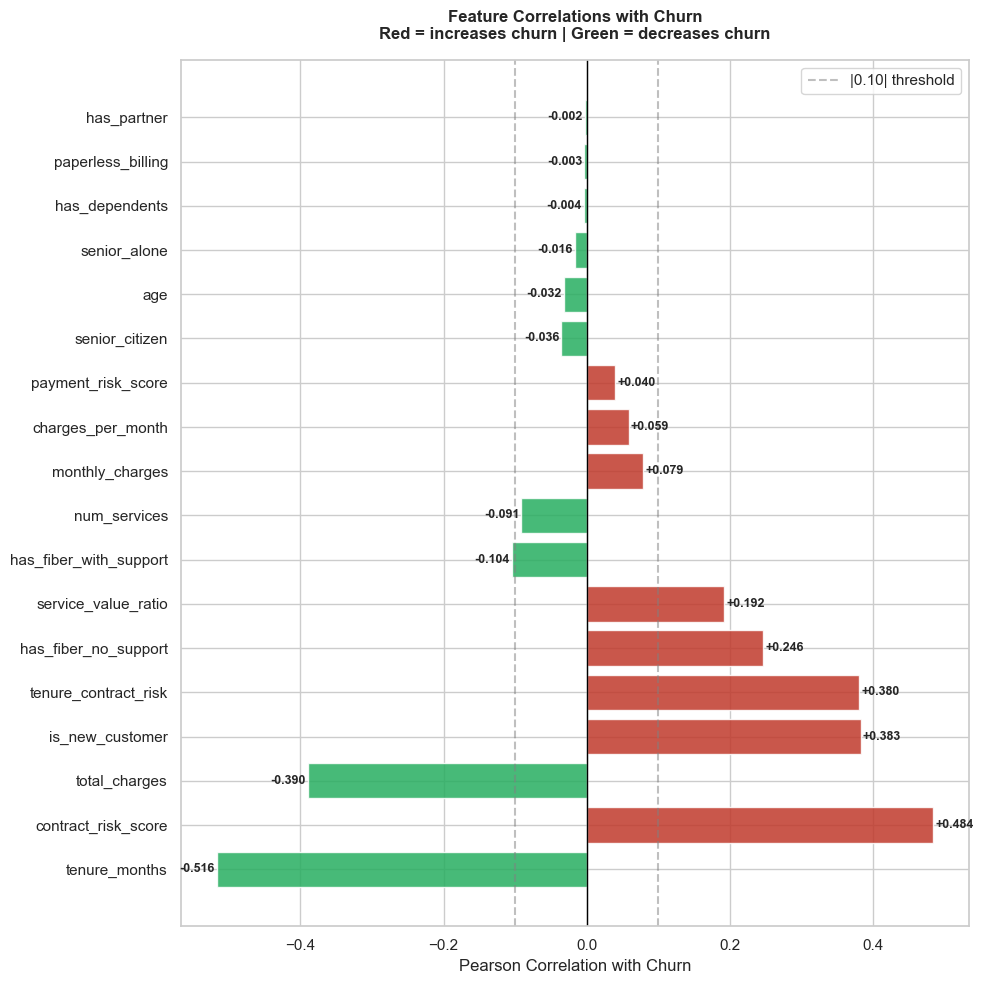


Top 5 features by absolute correlation :
tenure_months          -0.516341
contract_risk_score     0.483526
total_charges          -0.389572
is_new_customer         0.382564
tenure_contract_risk    0.380293

Bottom 5 features (weakest signal) :
age                 -0.032350
senior_alone        -0.016126
has_dependents      -0.004172
paperless_billing   -0.003458
has_partner         -0.002104


In [34]:
print("── CORRELATION ANALYSIS : ALL FEATURES vs CHURN ──")

# Numeric features only for correlation
numeric_features = [
    'tenure_months', 'monthly_charges', 'total_charges',
    'age', 'num_services', 'senior_citizen',
    'has_partner', 'has_dependents', 'paperless_billing',
    # New engineered features
    'charges_per_month', 'is_new_customer',
    'contract_risk_score', 'has_fiber_no_support',
    'has_fiber_with_support', 'service_value_ratio',
    'senior_alone', 'payment_risk_score',
    'tenure_contract_risk',
    'churn'
]

corr_df = df[numeric_features].corr()['churn'].drop('churn')
corr_df = corr_df.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#c0392b' if v > 0 else '#27ae60'
          for v in corr_df.values]
bars = ax.barh(corr_df.index, corr_df.values,
               color=colors, alpha=0.85,
               edgecolor='white', linewidth=1)

# Value labels
for bar, val in zip(bars, corr_df.values):
    ax.text(
        val + (0.003 if val >= 0 else -0.003),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9, fontweight='bold'
    )

ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=0.1, color='gray', linestyle='--',
           alpha=0.5, label='|0.10| threshold')
ax.axvline(x=-0.1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Pearson Correlation with Churn', fontsize=12)
ax.set_title('Feature Correlations with Churn\n'
             'Red = increases churn | Green = decreases churn',
             fontweight='bold', pad=15)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / '13_feature_correlations.png',
            bbox_inches='tight')
plt.show()

print("\nTop 5 features by absolute correlation :")
print(corr_df.head().to_string())
print("\nBottom 5 features (weakest signal) :")
print(corr_df.tail().to_string())

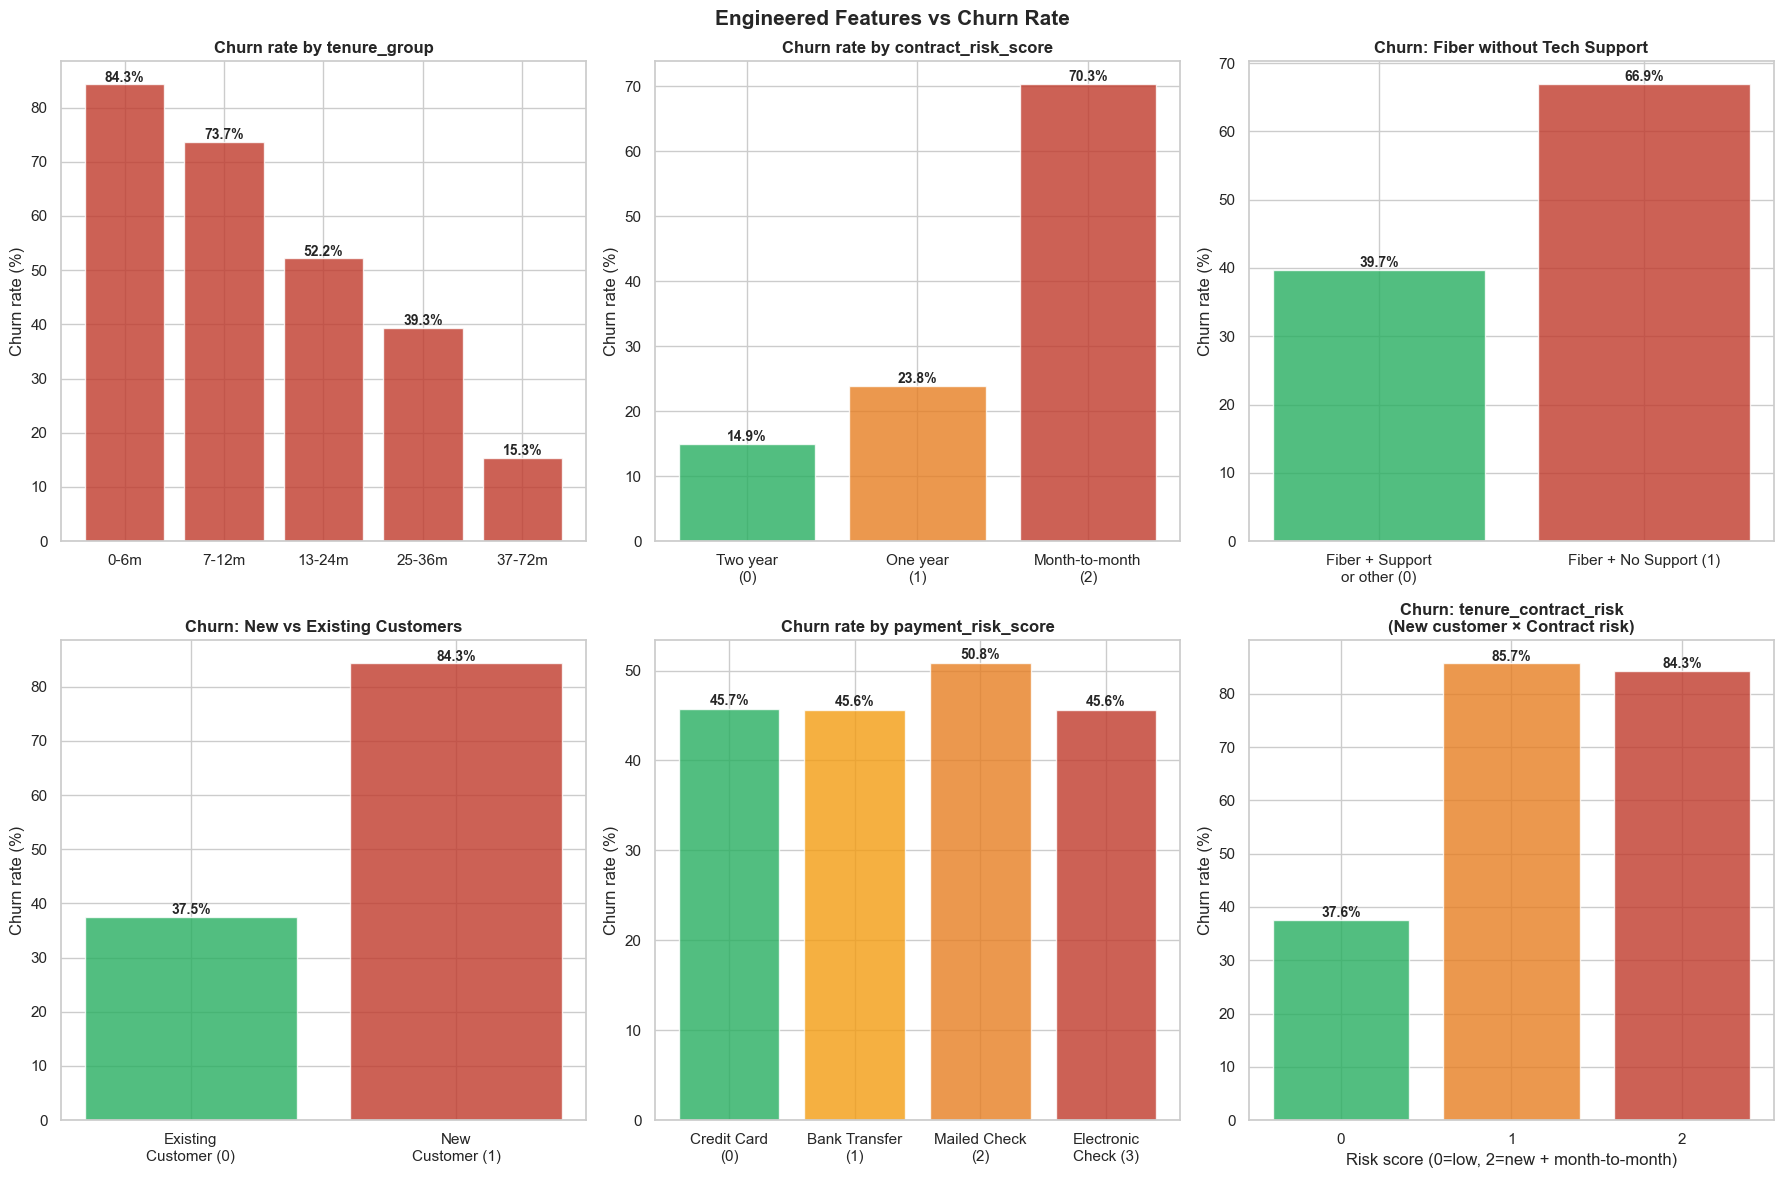

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1 — tenure_group
temp = (df.groupby('tenure_group', observed=True)['churn']
        .mean() * 100).round(1)
axes[0,0].bar(temp.index.astype(str), temp.values,
              color='#c0392b', alpha=0.8)
axes[0,0].set_title('Churn rate by tenure_group',
                     fontweight='bold')
axes[0,0].set_ylabel('Churn rate (%)')
for i, v in enumerate(temp.values):
    axes[0,0].text(i, v+0.5, f'{v}%', ha='center',
                   fontsize=10, fontweight='bold')

# 2 — contract_risk_score
temp2 = (df.groupby('contract_risk_score')['churn']
         .mean() * 100).round(1)
axes[0,1].bar(
    ['Two year\n(0)', 'One year\n(1)', 'Month-to-month\n(2)'],
    temp2.sort_index().values,
    color=['#27ae60', '#e67e22', '#c0392b'], alpha=0.8
)
axes[0,1].set_title('Churn rate by contract_risk_score',
                     fontweight='bold')
axes[0,1].set_ylabel('Churn rate (%)')
for i, v in enumerate(temp2.sort_index().values):
    axes[0,1].text(i, v+0.5, f'{v}%', ha='center',
                   fontsize=10, fontweight='bold')

# 3 — has_fiber_no_support
temp3 = (df.groupby('has_fiber_no_support')['churn']
         .mean() * 100).round(1)
axes[0,2].bar(['Fiber + Support\nor other (0)',
               'Fiber + No Support (1)'],
              temp3.values,
              color=['#27ae60', '#c0392b'], alpha=0.8)
axes[0,2].set_title('Churn: Fiber without Tech Support',
                     fontweight='bold')
axes[0,2].set_ylabel('Churn rate (%)')
for i, v in enumerate(temp3.values):
    axes[0,2].text(i, v+0.5, f'{v}%', ha='center',
                   fontsize=10, fontweight='bold')

# 4 — is_new_customer
temp4 = (df.groupby('is_new_customer')['churn']
         .mean() * 100).round(1)
axes[1,0].bar(['Existing\nCustomer (0)', 'New\nCustomer (1)'],
              temp4.values,
              color=['#27ae60', '#c0392b'], alpha=0.8)
axes[1,0].set_title('Churn: New vs Existing Customers',
                     fontweight='bold')
axes[1,0].set_ylabel('Churn rate (%)')
for i, v in enumerate(temp4.values):
    axes[1,0].text(i, v+0.5, f'{v}%', ha='center',
                   fontsize=10, fontweight='bold')

# 5 — payment_risk_score
temp5 = (df.groupby('payment_risk_score')['churn']
         .mean() * 100).round(1)
axes[1,1].bar(
    ['Credit Card\n(0)', 'Bank Transfer\n(1)',
     'Mailed Check\n(2)', 'Electronic\nCheck (3)'],
    temp5.sort_index().values,
    color=['#27ae60','#f39c12','#e67e22','#c0392b'],
    alpha=0.8
)
axes[1,1].set_title('Churn rate by payment_risk_score',
                     fontweight='bold')
axes[1,1].set_ylabel('Churn rate (%)')
for i, v in enumerate(temp5.sort_index().values):
    axes[1,1].text(i, v+0.5, f'{v}%', ha='center',
                   fontsize=10, fontweight='bold')

# 6 — tenure_contract_risk
temp6 = (df.groupby('tenure_contract_risk')['churn']
         .mean() * 100).round(1)
bar_colors_6 = ['#27ae60', '#e67e22', '#c0392b']
axes[1,2].bar(temp6.index.astype(str), temp6.values,
              color=bar_colors_6, alpha=0.8)
axes[1,2].set_title('Churn: tenure_contract_risk\n'
                     '(New customer × Contract risk)',
                     fontweight='bold')
axes[1,2].set_ylabel('Churn rate (%)')
axes[1,2].set_xlabel('Risk score (0=low, 2=new + month-to-month)')
for i, v in enumerate(temp6.values):
    axes[1,2].text(i, v+0.5, f'{v}%', ha='center',
                   fontsize=10, fontweight='bold')

plt.suptitle('Engineered Features vs Churn Rate',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '14_engineered_features_churn.png',
            bbox_inches='tight')
plt.show()

In [36]:
print("── FINAL FEATURE MATRIX ──")

# One-hot encode remaining categorical columns
# We do this HERE for the saved feature matrix.
# In the sklearn Pipeline (for the API) this is handled
# by ColumnTransformer — never apply get_dummies to
# production inference data directly.

df_encoded = df.copy()

# Drop tenure_group and monthly_charge_group string versions
# Keep the numeric engineered features
df_encoded = df_encoded.drop(
    columns=['tenure_group', 'monthly_charge_group'],
    errors='ignore'
)

# One-hot encode categoricals
cat_cols_to_encode = [
    'gender', 'contract', 'internet_service',
    'online_security', 'tech_support',
    'streaming_tv', 'payment_method'
]

df_encoded = pd.get_dummies(
    df_encoded,
    columns=cat_cols_to_encode,
    drop_first=False,
    dtype=int
)

print(f"Shape before encoding : {df.shape}")
print(f"Shape after encoding  : {df_encoded.shape}")
print(f"\nNew columns added     : "
      f"{df_encoded.shape[1] - df.shape[1]}")
print(f"Nulls remaining       : "
      f"{df_encoded.isnull().sum().sum()}")

# Final feature list
feature_cols = [c for c in df_encoded.columns
                if c != 'churn']
print(f"\nTotal features for modeling : {len(feature_cols)}")

── FINAL FEATURE MATRIX ──
Shape before encoding : (15025, 28)
Shape after encoding  : (15025, 37)

New columns added     : 9
Nulls remaining       : 0

Total features for modeling : 36


── MUTUAL INFORMATION — FEATURE RELEVANCE ──
(Quick pre-model check — not final importance)


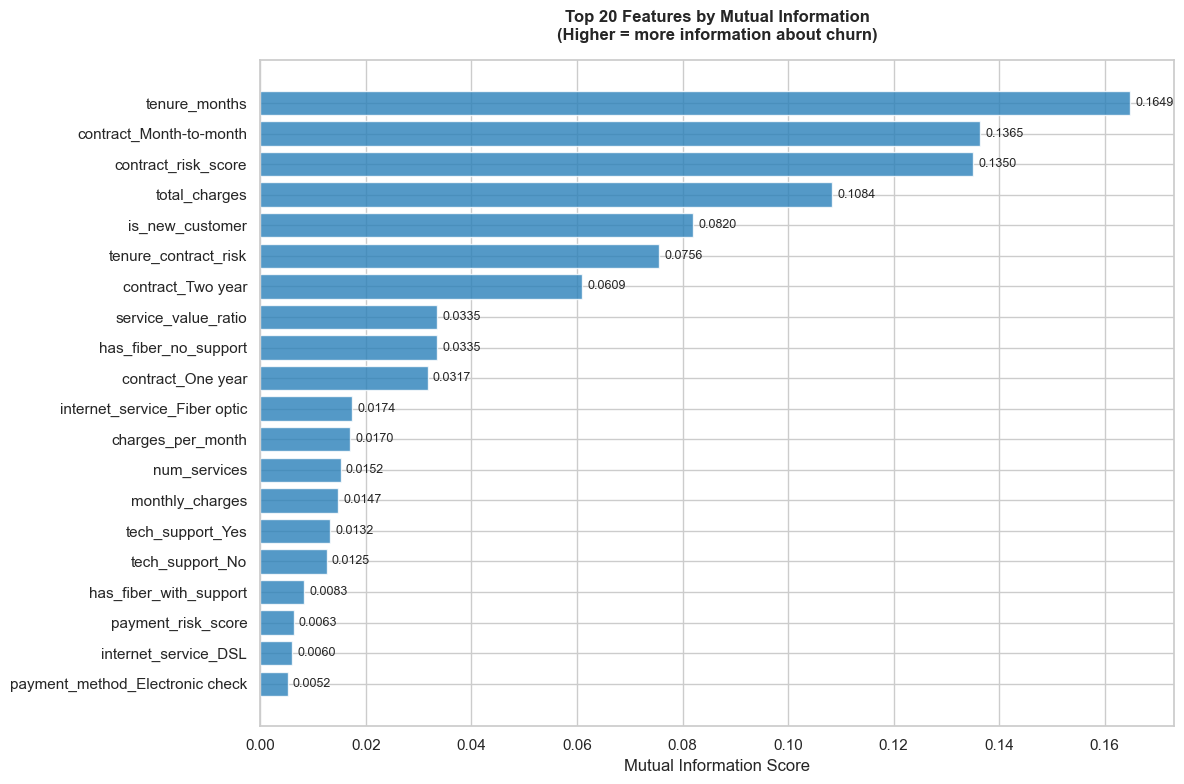


Top 10 features by mutual information :
  tenure_months                       0.1649
  contract_Month-to-month             0.1365
  contract_risk_score                 0.1350
  total_charges                       0.1084
  is_new_customer                     0.0820
  tenure_contract_risk                0.0756
  contract_Two year                   0.0609
  service_value_ratio                 0.0335
  has_fiber_no_support                0.0335
  contract_One year                   0.0317

→ Features with MI > 0.01 are worth keeping
→ Features with MI ≈ 0.000 may be dropped


In [37]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

print("── MUTUAL INFORMATION — FEATURE RELEVANCE ──")
print("(Quick pre-model check — not final importance)")

X = df_encoded[[c for c in df_encoded.columns
                if c != 'churn']].copy()
y = df_encoded['churn']

# Compute mutual information
mi_scores = mutual_info_classif(
    X, y, random_state=42
)
mi_series = pd.Series(
    mi_scores, index=X.columns
).sort_values(ascending=False)

# Plot top 20
top20 = mi_series.head(20)
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top20.index[::-1], top20.values[::-1],
               color='#2980b9', alpha=0.8)
ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_title('Top 20 Features by Mutual Information\n'
             '(Higher = more information about churn)',
             fontweight='bold', pad=15)

for bar, val in zip(bars, top20.values[::-1]):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_PATH / '15_mutual_information.png',
            bbox_inches='tight')
plt.show()

print("\nTop 10 features by mutual information :")
for feat, score in mi_series.head(10).items():
    print(f"  {feat:<35} {score:.4f}")

print("\n→ Features with MI > 0.01 are worth keeping")
print("→ Features with MI ≈ 0.000 may be dropped")

In [38]:
print("── SAVING FEATURE-ENGINEERED DATASETS ──")

# Dataset with engineered features (before one-hot encoding)
# This is what you use for EDA and visualization
df_features = df.copy()
df_features.to_parquet(
    DATA_PROCESSED / 'telecom_features.parquet',
    index=False
)

# Fully encoded matrix — ready for sklearn
X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

X.to_parquet(
    DATA_PROCESSED / 'X_features.parquet',
    index=False
)
y.to_frame().to_parquet(
    DATA_PROCESSED / 'y_target.parquet',
    index=False
)

# Save feature names list for API validation
import json
feature_names = list(X.columns)
with open(DATA_PROCESSED / 'feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)

print(f"Files saved in data/processed/ :")
print(f"  telecom_features.parquet   "
      f"← with engineered features")
print(f"  X_features.parquet         "
      f"← encoded feature matrix")
print(f"  y_target.parquet           "
      f"← target variable")
print(f"  feature_names.json         "
      f"← feature list for API")
print(f"\nFinal shapes :")
print(f"  X : {X.shape}")
print(f"  y : {y.shape}")
print(f"  Churn rate : {y.mean():.1%}")

# Validation
assert X.isnull().sum().sum() == 0
assert len(X) == len(y)
assert set(y.unique()) == {0, 1}
print(f"\n✓ All validation checks passed")

── SAVING FEATURE-ENGINEERED DATASETS ──
Files saved in data/processed/ :
  telecom_features.parquet   ← with engineered features
  X_features.parquet         ← encoded feature matrix
  y_target.parquet           ← target variable
  feature_names.json         ← feature list for API

Final shapes :
  X : (15025, 36)
  y : (15025,)
  Churn rate : 47.4%

✓ All validation checks passed


## 📋 Feature Engineering Summary

### Features Created (10 total)

| Feature | Type | Rationale | Churn Signal |
|---------|------|-----------|-------------|
| `tenure_group` | Ordinal bucket | Non-linear relationship with churn | Strong |
| `charges_per_month` | Continuous ratio | Payment consistency proxy | Medium |
| `is_new_customer` | Binary flag | Tenure ≤ 6 months = highest risk | Strong |
| `contract_risk_score` | Ordinal (0–2) | Natural risk ordering in contract type | Strong |
| `has_fiber_no_support` | Binary interaction | Fiber + no tech support = frustration | Strong |
| `has_fiber_with_support` | Binary interaction | Retention signal for Fiber users | Medium |
| `service_value_ratio` | Continuous ratio | Monthly charges per service unit | Medium |
| `monthly_charge_group` | Ordinal bucket | Price sensitivity tiers | Medium |
| `senior_alone` | Binary interaction | Senior + no household = easy to cancel | Medium |
| `payment_risk_score` | Ordinal (0–3) | Electronic check = highest churn risk | Medium |
| `tenure_contract_risk` | Interaction score | New + month-to-month = compounded risk | Strong |

### Key Design Decisions

- **No encoding in this notebook** — encoding happens inside the
  sklearn Pipeline to prevent train-serve skew
- **Bucketed features kept alongside continuous** — both versions
  tested during modeling to find what works best
- **Interaction features** — XGBoost can learn interactions, but
  explicit features improve interpretability and SHAP explanations
- **feature_names.json saved** — ensures the API receives and
  validates exactly the right feature set

### What Comes Next
1. Build sklearn Pipeline (imputer → encoder → scaler)
2. Train/test split — stratified by churn
3. Baseline model → Logistic Regression → XGBoost
4. Hyperparameter tuning with Optuna
5. Threshold optimization using F1 curve